# Semana 9 — Projeto Prático de Data Warehouse e Modelagem Dimensional - SQL

Mini Data Warehouse de e-commerce usando o dataset Olist.

## Objetivos

- Diferenciar OLTP e OLAP
- Executar ETL com Pandas
- Criar dimensões e tabela fato
- Identificar PK, FK e Surrogate Key
- Criar Star Schema
- Consultar o modelo com SQL
- Interpretar métricas de BI

## Arquivos necessários

Baixe no Kaggle o dataset Brazilian E-Commerce Public Dataset by Olist e coloque na pasta do notebook:

- olist_orders_dataset.csv
- olist_order_items_dataset.csv
- olist_customers_dataset.csv
- olist_products_dataset.csv
- product_category_name_translation.csv

In [1]:
# Importa as bibliotecas necessárias para manipulação de dados, execução de consultas SQL e visualização.
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)

# 1. Cenário de negócio

O diretor quer responder:

1. Qual foi o faturamento total?
2. Quais estados mais faturaram?
3. Quais categorias mais venderam?
4. Qual foi o ticket médio?
5. Como o faturamento evoluiu ao longo do tempo?

# 2. Extract — carregando fontes OLTP

In [2]:
# Carrega os dados dos arquivos CSV para dataframes do pandas.
pedidos = pd.read_csv('/Users/Dell/Documents/GitHub/Semana_9/Dataset/olist_orders_dataset.csv')
itens = pd.read_csv('/Users/Dell/Documents/GitHub/Semana_9/Dataset/olist_order_items_dataset.csv')
clientes = pd.read_csv('/Users/Dell/Documents/GitHub/Semana_9/Dataset/olist_customers_dataset.csv')
produtos = pd.read_csv('/Users/Dell/Documents/GitHub/Semana_9/Dataset/olist_products_dataset.csv')
traducao_categoria = pd.read_csv('/Users/Dell/Documents/GitHub/Semana_9/Dataset/product_category_name_translation.csv')

print('orders:', pedidos.shape)
print('items:', itens.shape)
print('customers:', clientes.shape)
print('products:', produtos.shape)
print('category_translation:', traducao_categoria.shape)

orders: (99441, 8)
items: (112650, 7)
customers: (99441, 5)
products: (32951, 9)
category_translation: (71, 2)


## Exercício 1 🟢 Fácil — OLTP

Responda:

1. Por que essas tabelas podem ser consideradas fontes OLTP?
    
    Porque apresentam dados extraídos dos sistemas de forma agregada permitindo análises gerenciais.
2. Qual tabela registra o pedido?
    
    A tabela "pedidos"
3. Qual tabela registra os itens de cada pedido?
    
    A tabela "itens"
4. Qual tabela descreve os clientes?
    
    Tabela "clientes"
5. Qual tabela descreve os produtos?
    
    Tabela "produtos"

# 3. Análise exploratória inicial

In [3]:
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
itens.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
produtos.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## Exercício 2 🟢 Fácil — Explorando os dados

Use `.info()`, `.shape` e `.isnull().sum()` para investigar as tabelas.

In [7]:
# Investigue a tabela orders
# As tabelas orders e order_items estão relacionadas pela coluna order_id. A tabela orders contém informações sobre os pedidos, como o ID do cliente, a data do pedido e o status do pedido. A tabela order_items contém informações sobre os itens de cada pedido, como o ID do produto, a quantidade e o preço.
# As tabelas não contêm colunas com valores nulos, o que é um bom sinal para a qualidade dos dados. No entanto, é importante verificar se há valores duplicados ou inconsistentes nas tabelas, especialmente na tabela orders, onde o ID do pedido deve ser único.
# As datas de pedido estão no formato de string, o que pode dificultar a análise temporal. Devemos convertê-las para o formato datetime do pandas para facilitar a manipulação e análise de dados relacionados ao tempo.

pedidos.info()
itens.info()
clientes.info()
produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 no

In [8]:
# Investigue a tabela items
# A tabela items contém informações sobre os itens de cada pedido, como o ID do produto, a quantidade e o preço. 
# A tabela não contém colunas com valores nulos. No entanto, é importante verificar se há valores duplicados ou inconsistentes.

print('Quantidade de itens:', itens.shape[0])
print('Quantidade de itens duplicados:', itens.duplicated().sum())
print('\nQuantidade de valores nulos:')
itens.isnull().sum()


Quantidade de itens: 112650
Quantidade de itens duplicados: 0

Quantidade de valores nulos:


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [9]:
# Investigue a tabela customers
# A tabela customers contém informações sobre os clientes, como o ID do cliente, o estado de residência e a data de criação do cadastro.
# A tabela não contém colunas com valores nulos. No entanto, é importante verificar se há valores duplicados ou inconsistentes.

print('Quantidade de clientes:', clientes.shape[0])
print('Quantidade de clientes duplicados:', clientes.duplicated().sum())
print('\nQuantidade de valores nulos:')
clientes.isnull().sum()

Quantidade de clientes: 99441
Quantidade de clientes duplicados: 0

Quantidade de valores nulos:


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [10]:
# Investigue a tabela products
# A tabela products contém informações sobre os produtos, como o ID do produto, o nome do produto e a categoria do produto.
# Há valores nulos em algumas colunas, como product_category_name e product_description_lenght. Isso pode indicar que algumas informações sobre os produtos estão faltando, o que pode afetar a análise dos dados. 
# Além disso, é importante verificar se há valores duplicados ou inconsistentes na tabela products. 

print('Quantidade de produtos:', produtos.shape[0])
print('Quantidade de produtos duplicados:', produtos.duplicated().sum())
print('\nQuantidade de valores nulos:')
produtos.isnull().sum()


Quantidade de produtos: 32951
Quantidade de produtos duplicados: 0

Quantidade de valores nulos:


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

# 4. Transform — tratamento dos dados

Transformações comuns: converter tipos, remover duplicidades, tratar nulos, padronizar nomes e criar colunas derivadas.

In [11]:
pedidos['order_purchase_timestamp'] = pd.to_datetime(pedidos['order_purchase_timestamp'])
pedidos['order_approved_at'] = pd.to_datetime(pedidos['order_approved_at'])
pedidos['order_delivered_customer_date'] = pd.to_datetime(pedidos['order_delivered_customer_date'])
pedidos['order_estimated_delivery_date'] = pd.to_datetime(pedidos['order_estimated_delivery_date'])

pedidos[['order_purchase_timestamp', 'order_approved_at', 'order_delivered_customer_date']].head()

,order_purchase_timestamp,order_approved_at,order_delivered_customer_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-10 21:25:13
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-07 15:27:45
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-17 18:06:29
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-12-02 00:28:42
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-16 18:17:02


## Exercício 3 🟢 Fácil — Criando atributos de tempo

Crie as colunas `ano`, `mes`, `dia`, `trimestre` e `ano_mes` a partir de `order_purchase_timestamp`.

In [12]:
# A criação de colunas adicionais para ano, mês, dia, trimestre e ano-mês pode ser útil para análises temporais. 
# Dessa forma é possível identificar tendências sazonais ou comparar o desempenho de vendas em diferentes períodos. 
# Essas colunas permitem agrupar os dados de forma mais flexível e realizar análises mais detalhadas com base no tempo.

pedidos['order_purchase_timestamp'] = pd.to_datetime(pedidos['order_purchase_timestamp'])
pedidos['order_approved_at'] = pd.to_datetime(pedidos['order_approved_at'])
pedidos['order_delivered_customer_date'] = pd.to_datetime(pedidos['order_delivered_customer_date'])
pedidos['order_estimated_delivery_date'] = pd.to_datetime(pedidos['order_estimated_delivery_date'])
pedidos['ano'] = pedidos['order_purchase_timestamp'].dt.year
pedidos['mes'] = pedidos['order_purchase_timestamp'].dt.month
pedidos['dia'] = pedidos['order_purchase_timestamp'].dt.day
pedidos['trimestre'] = pedidos['order_purchase_timestamp'].dt.quarter
pedidos['ano_mes'] = pedidos['order_purchase_timestamp'].dt.to_period('M').astype(str)
pedidos[['order_purchase_timestamp', 'ano', 'mes', 'dia', 'trimestre', 'ano_mes']].head()

,order_purchase_timestamp,ano,mes,dia,trimestre,ano_mes
0,2017-10-02 10:56:33,2017,10,2,4,2017-10
1,2018-07-24 20:41:37,2018,7,24,3,2018-07
2,2018-08-08 08:38:49,2018,8,8,3,2018-08
3,2017-11-18 19:28:06,2017,11,18,4,2017-11
4,2018-02-13 21:18:39,2018,2,13,1,2018-02


## Exercício 4 🟢 Fácil — Remoção de duplicidades

Verifique se existem duplicidades nas tabelas principais e remova-as.

In [13]:
# Verifica a existência de valores duplicados em cada tabela.
print('Duplicados orders:', pedidos.duplicated().sum())
print('Duplicados items:', itens.duplicated().sum())
print('Duplicados customers:', clientes.duplicated().sum())
print('Duplicados products:', produtos.duplicated().sum())

# Remove duplicados se existirem.
pedidos = pedidos.drop_duplicates()
itens = itens.drop_duplicates()
clientes = clientes.drop_duplicates()
produtos = produtos.drop_duplicates()


Duplicados orders: 0
Duplicados items: 0
Duplicados customers: 0
Duplicados products: 0


## Exercício 5 🟡 Médio — Filtro de pedidos válidos

Considere apenas pedidos com status `delivered` e crie `pedidos_entregues`.

In [14]:
# Cria um dataframe apenas com os pedidos entregues ('order_status' == 'delivered').

pedidos_entregues = pedidos[pedidos['order_status'] == 'delivered'].copy()
print(pedidos_entregues.shape)
pedidos_entregues.info()


(96478, 13)
<class 'pandas.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  str           
 1   customer_id                    96478 non-null  str           
 2   order_status                   96478 non-null  str           
 3   order_purchase_timestamp       96478 non-null  datetime64[us]
 4   order_approved_at              96464 non-null  datetime64[us]
 5   order_delivered_carrier_date   96476 non-null  str           
 6   order_delivered_customer_date  96470 non-null  datetime64[us]
 7   order_estimated_delivery_date  96478 non-null  datetime64[us]
 8   ano                            96478 non-null  int32         
 9   mes                            96478 non-null  int32         
 10  dia                            96478 non-null  int32         
 11  trimestre          

# 5. Modelagem dimensional

Modelo esperado:

```text
dim_cliente
     |
dim_produto -- fato_vendas -- dim_tempo
```

A tabela fato guarda eventos mensuráveis. As dimensões guardam contexto.

# 6. Criando a dimensão cliente

In [15]:
# Cria a dimensão cliente a partir da tabela customers, garantindo que cada cliente seja representado apenas uma vez.
dim_cliente = clientes[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']].drop_duplicates().copy()
# Reseta o índice para garantir que a coluna cliente_sk seja criada corretamente.
dim_cliente = dim_cliente.reset_index(drop=True) 
# A coluna cliente_sk é criada a partir do índice do dataframe, garantindo que cada cliente tenha um identificador único.
dim_cliente['cliente_sk'] = dim_cliente.index + 1 
# Reordena as colunas para colocar cliente_sk no início.
dim_cliente = dim_cliente[['cliente_sk', 'customer_id', 'customer_unique_id', 'customer_city', 'customer_state']] 

dim_cliente.head()

,cliente_sk,customer_id,customer_unique_id,customer_city,customer_state
0,1,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP
1,2,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP
2,3,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP
3,4,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP
4,5,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP


## Exercício 6 🟡 Médio — PK, SK e chave natural

1. Qual coluna é a Surrogate Key da dimensão cliente?

    Foi criada a Surrogate Key em 'cliente_sk'
2. Qual coluna veio do sistema de origem?

    A chave primária do sistema principal é 'customer_id'
3. Por que não usar CPF, e-mail ou código da origem como PK física do DW?

    Essa informações devem ser mantidas no sistema de origem porque se referem a dados de transações específicas não sendo úteis para análises agragadas em um data warehouse analítico. CPF e e-mail podem ser consideradas informações sensíveis e devem ser evitadas no data warehouse.

# 7. Criando a dimensão produto

In [16]:
# Cria a dimensão produto a partir da tabela products, contendo as colunas 'product_id' e 'product_category_name'
# Remove duplicados para garantir que cada produto seja representado apenas uma vez.
dim_produto = produtos[['product_id', 'product_category_name']].drop_duplicates().copy() 

# Realiza um merge com a tabela de tradução para obter a categoria em inglês.
dim_produto = dim_produto.merge(traducao_categoria, on='product_category_name', how='left') 
# Preenche valores nulos com 'unknown' para categorias sem tradução.
dim_produto['product_category_name_english'] = dim_produto['product_category_name_english'].fillna('unknown') 
dim_produto = dim_produto.reset_index(drop=True)

# Cria a surrogate key na coluna produto_sk a partir do índice do dataframe, garantindo que cada produto tenha um identificador único.
dim_produto['produto_sk'] = dim_produto.index + 1 
# Reordena as colunas para colocar produto_sk no início.
dim_produto = dim_produto[['produto_sk', 'product_id', 'product_category_name', 'product_category_name_english']]
dim_produto.head()

,produto_sk,product_id,product_category_name,product_category_name_english
0,1,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,2,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,3,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,4,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,5,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


## Exercício 7 🟡 Médio — Star Schema vs Snowflake

1. Esse modelo se parece mais com Star Schema ou Snowflake?

    O modelo proposto se parece com um Star Schema
2. Como ficaria se categoria fosse uma tabela separada?

    Precisaríamos criar uma tabela dimensão "categorias". 
    O relacionamento entre as tabelas seria feito por meio de uma chave primária única em "categorias" e um campo contendo uma chave estrangeiras na tabela fato_vendas.
3. Qual opção costuma ser mais simples para Power BI?

    Um Star Schema costuma ser mais simples para o Power BI porque é uma estrutura mais simples e com menos JOIN.

# 8. Criando a dimensão tempo

In [17]:
#verifica se tem duplicidade de data e copia a tabela para criar a dimensão tempo

dim_tempo = pedidos_entregues[['order_purchase_timestamp']].drop_duplicates().copy()

### Crie as colunas necessárias para a dimensão tempo
dim_tempo['data'] = dim_tempo['order_purchase_timestamp'].dt.date #cria a coluna data apenas com a data, sem o horário
dim_tempo['ano'] = dim_tempo['order_purchase_timestamp'].dt.year #cria a coluna ano apenas com o ano da data
dim_tempo['mes'] = dim_tempo['order_purchase_timestamp'].dt.month #cria a coluna mes apenas com o mês da data
dim_tempo['dia'] = dim_tempo['order_purchase_timestamp'].dt.day #cria a coluna dia apenas com o dia da data
dim_tempo['trimestre'] = dim_tempo['order_purchase_timestamp'].dt.quarter #cria a coluna trimestre apenas com o trimestre da data


dim_tempo['ano_mes'] = dim_tempo['order_purchase_timestamp'].dt.to_period('M').astype(str) #cria a coluna ano_mes apenas com o ano e o mês da data, no formato "YYYY-MM"
dim_tempo = dim_tempo.drop_duplicates('data').reset_index(drop=True) #remove as linhas duplicadas com base na coluna data e reseta o índice
dim_tempo['tempo_sk'] = dim_tempo.index + 1 #cria a coluna tempo_sk com os valores sequenciais
dim_tempo = dim_tempo[['tempo_sk', 'data', 'ano', 'mes', 'dia', 'trimestre', 'ano_mes']] #reordena as colunas da dimensão tempo
dim_tempo.head() #exibe as primeiras linhas da dimensão tempo

,tempo_sk,data,ano,mes,dia,trimestre,ano_mes
0,1,2017-10-02,2017,10,2,4,2017-10
1,2,2018-07-24,2018,7,24,3,2018-07
2,3,2018-08-08,2018,8,8,3,2018-08
3,4,2017-11-18,2017,11,18,4,2017-11
4,5,2018-02-13,2018,2,13,1,2018-02


## Exercício 8 🟡 Médio — Dimensão tempo

1. Por que uma dimensão tempo é útil em BI?

    Porque permite a agregação dos dados por períodos de tempo
2. Que análises ela permite?

    A dimensão tempo é útil, por exemplo, para agragar dados de vendas, pedidos/entregas diárias, mensais, trimestrais ou anuais.
3. Qual coluna é a SK da dimensão tempo?

    tempo_sk

# 9. Criando a tabela fato

Evento: um item vendido dentro de um pedido.

Granularidade: uma linha por item vendido em um pedido.

In [18]:
# Cria a tabela fato_vendas a partir da tabela items, incluindo as colunas order_id, order_item_id, product_id, price e freight_value.
fato_vendas = itens[['order_id', 'order_item_id', 'product_id', 'price', 'freight_value']].copy()

# Fazer um merge com a tabela de pedidos entregues para incluir as colunas customer_id e order_purchase_timestamp, garantindo que apenas os pedidos entregues sejam incluídos na tabela fato_vendas.
# on='order_id' garante que o merge seja feito com base na coluna order_id, 
# how='inner' garante que apenas os pedidos entregues sejam incluídos na tabela fato_vendas, pois o merge só manterá as linhas que tiverem correspondência em ambas as tabelas.
fato_vendas = fato_vendas.merge(pedidos_entregues[['order_id', 'customer_id', 'order_purchase_timestamp']], on='order_id', how='inner') 
fato_vendas.head()

,order_id,order_item_id,product_id,price,freight_value,customer_id,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51


## Exercício 9 🟡 Médio — Relacionando fato e dimensões

Complete a construção da `fato_vendas` trazendo `cliente_sk`, `produto_sk` e `tempo_sk`.

In [19]:
# A criação da tabela fato_vendas envolve a junção de várias tabelas para incluir as chaves estrangeiras
# das dimensões cliente, produto e tempo.
#
# faz um merge com a dimensão cliente para incluir a coluna cliente_sk na tabela fato_vendas, usando a coluna customer_id como chave de junção
fato_vendas = fato_vendas.merge(dim_cliente[['cliente_sk', 'customer_id']], on='customer_id', how='left') 
# Faz um merge com a dimensão produto para incluir a coluna produto_sk na tabela fato_vendas, usando a coluna product_id como chave de junção
fato_vendas = fato_vendas.merge(dim_produto[['produto_sk', 'product_id']], on='product_id', how='left')
# A coluna data é criada a partir da coluna order_purchase_timestamp, extraindo apenas a parte da data (sem o horário) para facilitar o merge com a dimensão tempo.
fato_vendas['data'] = fato_vendas['order_purchase_timestamp'].dt.date
# Faz um merge com a dimensão tempo para incluir a coluna tempo_sk na tabela fato_vendas, usando a coluna data como chave de junção
fato_vendas = fato_vendas.merge(dim_tempo[['tempo_sk', 'data']], on='data', how='left')
fato_vendas.head()

,order_id,order_item_id,product_id,price,freight_value,customer_id,order_purchase_timestamp,cliente_sk,produto_sk,data,tempo_sk
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,65558,25866,2017-09-13,64
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,34266,27231,2017-04-26,125
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,34956,22625,2018-01-14,222
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,51764,15404,2018-08-08,3
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,7603,8863,2017-02-04,512


## Exercício 10 🟡 Médio — Métricas da fato

Crie `valor_produto`, `valor_frete` e `valor_total`.

In [20]:
# Adiciona colunas para os valores na tabela fato_vendas, calculando o valor total como a soma do valor do produto e do valor do frete.
fato_vendas['valor_produto'] = fato_vendas['price']
fato_vendas['valor_frete'] = fato_vendas['freight_value']
fato_vendas['valor_total'] = fato_vendas['valor_produto'] + fato_vendas['valor_frete']

fato_vendas.head()

,order_id,order_item_id,product_id,price,freight_value,customer_id,order_purchase_timestamp,cliente_sk,produto_sk,data,tempo_sk,valor_produto,valor_frete,valor_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,65558,25866,2017-09-13,64,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,34266,27231,2017-04-26,125,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,34956,22625,2018-01-14,222,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,51764,15404,2018-08-08,3,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,7603,8863,2017-02-04,512,199.90,18.14,218.04


## Exercício 11 🔴 Difícil — Fato final

Deixe a fato com: `order_id`, `order_item_id`, `cliente_sk`, `produto_sk`, `tempo_sk`, `valor_produto`, `valor_frete`, `valor_total`.

Depois, crie `venda_sk`.

In [21]:
# Cria o dataframe fato_vendas_final com as colunas necessárias para a tabela fato.
fato_vendas_final = fato_vendas[['order_id','order_item_id','cliente_sk','produto_sk','tempo_sk','valor_produto','valor_frete','valor_total']].copy()
fato_vendas_final = fato_vendas_final.reset_index(drop=True)
# Adiciona a coluna venda_sk como chave primária da tabela fato_vendas_final, garantindo que cada venda tenha um identificador único.
fato_vendas_final['venda_sk'] = fato_vendas_final.index + 1
# Reordena as colunas para colocar venda_sk no início.
fato_vendas_final = fato_vendas_final[['venda_sk','order_id','order_item_id','cliente_sk','produto_sk','tempo_sk','valor_produto','valor_frete','valor_total']]
fato_vendas_final.head()

,venda_sk,order_id,order_item_id,cliente_sk,produto_sk,tempo_sk,valor_produto,valor_frete,valor_total
0,1,00010242fe8c5a6d1ba2dd792cb16214,1,65558,25866,64,58.90,13.29,72.19
1,2,00018f77f2f0320c557190d7a144bdd3,1,34266,27231,125,239.90,19.93,259.83
2,3,000229ec398224ef6ca0657da4fc703e,1,34956,22625,222,199.00,17.87,216.87
3,4,00024acbcdf0a6daa1e931b038114c75,1,51764,15404,3,12.99,12.79,25.78
4,5,00042b26cf59d7ce69dfabb4e55b4fd9,1,7603,8863,512,199.90,18.14,218.04


# 10. Validando o Star Schema

## Exercício 12 🔴 Difícil — Documentação do modelo


| Tabela | Tipo | PK | FK | Descrição |
|---|---|---|---|---|
| dim_cliente | Dimensão | cliente_sk | - | Contexto do cliente |
| dim_produto | Dimensão | produto_sk | - | Contexto do produto |
| dim_tempo | Dimensão | tempo_sk | - | Contexto temporal |
| fato_vendas | Fato | venda_sk | cliente_sk, produto_sk, tempo_sk | Evento mensurável de venda |

Granularidade: uma linha por item vendido por pedido.

# 11. SQL Analítico com DuckDB

In [22]:
con = duckdb.connect()
con.register('dim_cliente', dim_cliente) # registra a dimensão cliente no banco de dados
con.register('dim_produto', dim_produto) # registra a dimensão produto no banco de dados
con.register('dim_tempo', dim_tempo) # registra a dimensão tempo no banco de dados
con.register('fato_vendas', fato_vendas_final) # registra a tabela fato vendas no banco de dados

# Semana 9 — SQL para Data Warehouse

Nesta semana, vamos sair da etapa de construção do modelo dimensional e usar o Star Schema para responder perguntas de BI com SQL.

## Objetivos da Semana 9

Ao final das 3 aulas, você deverá conseguir:

- Usar `SELECT`, `WHERE` e `ORDER BY` em consultas analíticas.
- Fazer `INNER JOIN` entre tabela fato e dimensões.
- Usar `LEFT JOIN` para investigar ausência de relacionamento.
- Criar métricas com `GROUP BY`, `SUM`, `COUNT` e `AVG`.
- Filtrar agregações com `HAVING`.
- Usar funções de data como `DATE_TRUNC` e `EXTRACT`.

## Aula 1 da Semana 9 — SQL básico em DW

### Roteiro teórico

Em um Data Warehouse, o SQL é usado principalmente para análise.  
Diferente de um sistema transacional, onde o foco é inserir e atualizar registros, aqui o foco é consultar, agregar e transformar dados em indicadores.

A estrutura básica de uma consulta é:

```sql
SELECT colunas
FROM tabela
WHERE condição
ORDER BY coluna;
```

No nosso modelo:

- `fato_vendas` guarda os eventos mensuráveis de venda.
- `dim_cliente` explica quem comprou e onde.
- `dim_produto` explica o que foi vendido.
- `dim_tempo` permite analisar a venda no tempo.

## Consulta exemplo — Faturamento total

In [23]:
con.sql("""
SELECT SUM(valor_total) AS faturamento_total
FROM fato_vendas
""").df() # consulta para calcular o faturamento total da loja, somando a coluna valor_total da tabela fato_vendas

,faturamento_total
0,1.541977e+07


### Exemplo - Selecionando dados da tabela fato

In [24]:
con.sql("""
SELECT
    venda_sk,
    order_id,
    valor_produto,
    valor_frete,
    valor_total
FROM fato_vendas
LIMIT 20
""").df()

,venda_sk,order_id,valor_produto,valor_frete,valor_total
0,1,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,2,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,3,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,4,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,5,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04
5,6,00048cc3ae777c65dbb7d2a0634bc1ea,21.90,12.69,34.59
6,7,00054e8431b9d7675808bcb819fb4a32,19.90,11.85,31.75
7,8,000576fe39319847cbb9d288c5617fa6,810.00,70.75,880.75
8,9,0005a1a1728c9d785b8e2b08b904576c,145.95,11.65,157.60
9,10,0005f50442cb953dcd1d21e1fb923495,53.99,11.40,65.39


### Exemplo — usando `WHERE` e `ORDER BY`


In [25]:
con.sql("""SELECT
   venda_sk,
   order_id,
   valor_produto,
   valor_frete,
   valor_total
FROM fato_vendas
WHERE valor_total>500
ORDER BY valor_total DESC
LIMIT 20
""").df()

,venda_sk,order_id,valor_produto,valor_frete,valor_total
0,3482,0812eb902a67711a1cb742b3cdaa65ae,6735.00,194.31,6929.31
1,109785,fefacc66af859508bf1a7934eab1e97f,6729.00,193.21,6922.21
2,105496,f5136e38d1a14a4dbd87dff67da82701,6499.00,227.66,6726.66
3,72721,a96610ab360d42a2e5335a3998b4718a,4799.00,151.34,4950.34
4,10998,199af31afc78c699f0dbf71fb178d4d4,4690.00,74.34,4764.34
5,60712,8dbc85d1447242f3b127dda390d56e19,4590.00,91.78,4681.78
6,28537,426a9742b533fc6fed17d1fd6d143d7e,4399.87,113.45,4513.32
7,55421,80dfedb6d17bf23539beeef3c768f4d7,3999.00,195.76,4194.76
8,44822,68101694e5c5dc7330c91e1bbc36214f,4099.99,75.27,4175.26
9,76618,b239ca7cd485940b31882363b52e6674,4059.00,104.51,4163.51


### Exemplo — usando `WHERE` e `ORDER BY`

A consulta abaixo busca vendas com valor total maior que 200 e ordena da maior para a menor.

In [26]:
con.sql("""
SELECT
    venda_sk,
    order_id,
    valor_total
FROM fato_vendas
WHERE valor_total > 200
ORDER BY valor_total DESC
LIMIT 20
""").df()

,venda_sk,order_id,valor_total
0,3482,0812eb902a67711a1cb742b3cdaa65ae,6929.31
1,109785,fefacc66af859508bf1a7934eab1e97f,6922.21
2,105496,f5136e38d1a14a4dbd87dff67da82701,6726.66
3,72721,a96610ab360d42a2e5335a3998b4718a,4950.34
4,10998,199af31afc78c699f0dbf71fb178d4d4,4764.34
5,60712,8dbc85d1447242f3b127dda390d56e19,4681.78
6,28537,426a9742b533fc6fed17d1fd6d143d7e,4513.32
7,55421,80dfedb6d17bf23539beeef3c768f4d7,4194.76
8,44822,68101694e5c5dc7330c91e1bbc36214f,4175.26
9,76618,b239ca7cd485940b31882363b52e6674,4163.51


## Exercício 13 🟢 Fácil — SELECT em tabela fato

Liste as colunas `venda_sk`, `order_id`, `valor_produto`, `valor_frete` e `valor_total` das 15 primeiras vendas.

In [27]:
con.sql("""
SELECT
    venda_sk,
    order_id,
    valor_produto,
    valor_frete,
    valor_total
FROM fato_vendas
WHERE valor_total > 2000
ORDER BY valor_total DESC
LIMIT 15
""").df()

,venda_sk,order_id,valor_produto,valor_frete,valor_total
0,3482,0812eb902a67711a1cb742b3cdaa65ae,6735.00,194.31,6929.31
1,109785,fefacc66af859508bf1a7934eab1e97f,6729.00,193.21,6922.21
2,105496,f5136e38d1a14a4dbd87dff67da82701,6499.00,227.66,6726.66
3,72721,a96610ab360d42a2e5335a3998b4718a,4799.00,151.34,4950.34
4,10998,199af31afc78c699f0dbf71fb178d4d4,4690.00,74.34,4764.34
5,60712,8dbc85d1447242f3b127dda390d56e19,4590.00,91.78,4681.78
6,28537,426a9742b533fc6fed17d1fd6d143d7e,4399.87,113.45,4513.32
7,55421,80dfedb6d17bf23539beeef3c768f4d7,3999.00,195.76,4194.76
8,44822,68101694e5c5dc7330c91e1bbc36214f,4099.99,75.27,4175.26
9,76618,b239ca7cd485940b31882363b52e6674,4059.00,104.51,4163.51


## Exercício 14 🟢 Fácil — Filtro com WHERE

Liste as vendas cujo `valor_frete` seja maior que 50.  
Mostre `venda_sk`, `order_id`, `valor_frete` e `valor_total`.

In [28]:
con.sql("""SELECT
   venda_sk,
   order_id,
   valor_frete,
   valor_total
FROM fato_vendas
WHERE valor_frete>50
ORDER BY valor_frete DESC
LIMIT 20
""").df()

,venda_sk,order_id,valor_frete,valor_total
0,71885,a77e1550db865202c56b19ddc6dc4d53,409.68,1388.68
1,27413,3fde74c28a3d5d618c00f26d51baafa0,375.28,2713.36
2,3232,076d1555fb53a89b0ef4d529e527a0f6,375.28,2713.36
3,68275,9f49bd16053df810384e793386312674,339.59,1488.59
4,16360,264a7e199467906c0727394df82d1a6a,338.30,1388.30
5,86056,c7a07ddd52bbe18b61da49a8d89853d3,322.10,1372.10
6,4939,0b6230647ed16f4b3e70282dc4b5b87f,321.88,1371.88
7,3510,0822bcde10bb5d023755a71bc8f7797f,321.46,1311.46
8,29114,43bdbd9dc0931d72befdf4765af6c442,317.47,3406.47
9,47246,6ddfbf514959b49b6410c01ad93054bb,314.40,1359.40


## Exercício 15 🟡 Médio — Ordenação para ranking

Liste as 20 vendas de maior `valor_total`.  
Mostre `venda_sk`, `order_id`, `valor_produto`, `valor_frete` e `valor_total`.

In [29]:
con.sql("""SELECT
   venda_sk,
   order_id,
   valor_produto,
   valor_frete,
   valor_total
FROM fato_vendas
ORDER BY valor_total DESC
LIMIT 20
""").df()

,venda_sk,order_id,valor_produto,valor_frete,valor_total
0,3482,0812eb902a67711a1cb742b3cdaa65ae,6735.00,194.31,6929.31
1,109785,fefacc66af859508bf1a7934eab1e97f,6729.00,193.21,6922.21
2,105496,f5136e38d1a14a4dbd87dff67da82701,6499.00,227.66,6726.66
3,72721,a96610ab360d42a2e5335a3998b4718a,4799.00,151.34,4950.34
4,10998,199af31afc78c699f0dbf71fb178d4d4,4690.00,74.34,4764.34
5,60712,8dbc85d1447242f3b127dda390d56e19,4590.00,91.78,4681.78
6,28537,426a9742b533fc6fed17d1fd6d143d7e,4399.87,113.45,4513.32
7,55421,80dfedb6d17bf23539beeef3c768f4d7,3999.00,195.76,4194.76
8,44822,68101694e5c5dc7330c91e1bbc36214f,4099.99,75.27,4175.26
9,76618,b239ca7cd485940b31882363b52e6674,4059.00,104.51,4163.51


## Exercício do Slide 🟢 Fácil
Selecionar vendas com valor_total acima de um limite e ordenar do maior para o menor.

In [30]:
con.sql("""
SELECT
    venda_sk,
    order_id,
    valor_total
FROM fato_vendas
WHERE valor_total > 2000
ORDER BY valor_total DESC
LIMIT 20
""").df()

,venda_sk,order_id,valor_total
0,3482,0812eb902a67711a1cb742b3cdaa65ae,6929.31
1,109785,fefacc66af859508bf1a7934eab1e97f,6922.21
2,105496,f5136e38d1a14a4dbd87dff67da82701,6726.66
3,72721,a96610ab360d42a2e5335a3998b4718a,4950.34
4,10998,199af31afc78c699f0dbf71fb178d4d4,4764.34
5,60712,8dbc85d1447242f3b127dda390d56e19,4681.78
6,28537,426a9742b533fc6fed17d1fd6d143d7e,4513.32
7,55421,80dfedb6d17bf23539beeef3c768f4d7,4194.76
8,44822,68101694e5c5dc7330c91e1bbc36214f,4175.26
9,76618,b239ca7cd485940b31882363b52e6674,4163.51


## Exercício do Slide 🟡 Médio
Consultar vendas de uma categoria específica unindo fato_vendas e dim_produto.

In [31]:
con.sql("""
SELECT
    f.venda_sk,
    f.order_id,
    p.product_category_name_english AS categoria,
    c.customer_state,
    f.valor_total
    
FROM fato_vendas f

INNER JOIN dim_produto p
    ON f.produto_sk = p.produto_sk
INNER JOIN dim_cliente c
    ON f.cliente_sk = c.cliente_sk
WHERE categoria == 'art'
ORDER BY f.valor_total DESC
LIMIT 10
""").df()

,venda_sk,order_id,categoria,customer_state,valor_total
0,105496,f5136e38d1a14a4dbd87dff67da82701,art,SP,6726.66
1,28810,430bd310105f069ac72ef7758f40299b,art,SP,317.85
2,85880,c73b0385112900ca02c36977ef4796a8,art,SP,276.48
3,35459,5236307716393b7114b53ee991f36956,art,RJ,265.99
4,37802,57d7dd14ff04ad97e8fd20fbd41a358a,art,DF,249.16
5,55108,801d980e779937cd76e2cb8de056a680,art,RJ,207.94
6,97292,e18ebd6286697a3f0f6fe267d8286cb2,art,SP,165.91
7,20544,30192988070ccc8d5f5d40aad62b8ed4,art,SP,164.62
8,54568,7ed7752bf9dd6de1da9e4dced0e6e120,art,RJ,162.03
9,5906,0dac27d443a138000f35bd9137ecd1fc,art,RJ,161.46


## Exercício do Slide 🔴 Difícil
Identificar clientes sem vendas usando LEFT JOIN.

In [32]:
# Clientes sem vendas usando LEFT JOIN
con.sql("""
SELECT
    c.cliente_sk,
    c.customer_id,
    c.customer_city,
    c.customer_state    
FROM dim_cliente c
LEFT JOIN fato_vendas f
    ON c.cliente_sk = f.cliente_sk
WHERE f.cliente_sk IS NULL
LIMIT 20
""").df()

,cliente_sk,customer_id,customer_city,customer_state
0,47,f34a6e874087ec1f0e3dab9fdf659c5d,ituiutaba,MG
1,48,c132855c926907970dcf6f2bf0b33a24,taquarituba,SP
2,71,4c7241af24b5344cb01fe687643de4fe,fortaleza,CE
3,80,f6529ffebe6b3440d45d89604a4239ac,nova iguacu,RJ
4,101,ae76a4650235ab18764708174f1da31e,sao paulo,SP
5,114,8891eb5ca0e28df961b2b5b8f3c0eb23,sao paulo,SP
6,134,faafae37ddb3e4af81c10a397bcca35f,guarulhos,SP
7,225,265655cf1f2dfd4fc630004d1fe5f3cb,hortolandia,SP
8,247,3714eb406c7704a920e504085717ea5b,jaguariaiva,PR
9,289,5bfe800011656c0afb81db64519982db,aracatuba,SP


### JOIN

Em um Star Schema, normalmente a análise começa na tabela fato e depois se conecta às dimensões.

Exemplo de raciocínio:

> Quero faturamento por estado.  
> O faturamento está na `fato_vendas`.  
> O estado está na `dim_cliente`.  
> Então preciso fazer JOIN entre fato e dimensão cliente.

Tipos importantes:

- `INNER JOIN`: retorna apenas registros que possuem correspondência nos dois lados.
- `LEFT JOIN`: mantém todos os registros da tabela da esquerda, mesmo sem correspondência na direita.

### Exemplo — fato + dimensão cliente

In [33]:
con.sql("""
SELECT
    f.venda_sk,
    f.order_id,
    f.valor_total,
    c.customer_state
FROM fato_vendas f
INNER JOIN dim_cliente c
    ON f.cliente_sk = c.cliente_sk
LIMIT 10
""").df()

,venda_sk,order_id,valor_total,customer_state
0,1,00010242fe8c5a6d1ba2dd792cb16214,72.19,RJ
1,2,00018f77f2f0320c557190d7a144bdd3,259.83,SP
2,3,000229ec398224ef6ca0657da4fc703e,216.87,MG
3,4,00024acbcdf0a6daa1e931b038114c75,25.78,SP
4,5,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,SP
5,6,00048cc3ae777c65dbb7d2a0634bc1ea,34.59,MG
6,7,00054e8431b9d7675808bcb819fb4a32,31.75,SP
7,8,000576fe39319847cbb9d288c5617fa6,880.75,SP
8,9,0005a1a1728c9d785b8e2b08b904576c,157.60,SP
9,10,0005f50442cb953dcd1d21e1fb923495,65.39,SP


### Exemplo — fato + dimensão produto + dimensão tempo

In [34]:
con.sql("""
SELECT
    f.venda_sk,
    f.order_id,
    p.product_category_name_english AS categoria,
    c.customer_state,
    t.ano_mes,
    f.valor_total
    
FROM fato_vendas f
INNER JOIN dim_produto p
    ON f.produto_sk = p.produto_sk
INNER JOIN dim_tempo t
    ON f.tempo_sk = t.tempo_sk
INNER JOIN dim_cliente c
    ON f.cliente_sk = c.cliente_sk
ORDER BY f.valor_total DESC
LIMIT 10
""").df()

,venda_sk,order_id,categoria,customer_state,ano_mes,valor_total
0,3482,0812eb902a67711a1cb742b3cdaa65ae,housewares,MS,2017-02,6929.31
1,109785,fefacc66af859508bf1a7934eab1e97f,computers,ES,2018-07,6922.21
2,105496,f5136e38d1a14a4dbd87dff67da82701,art,SP,2017-05,6726.66
3,72721,a96610ab360d42a2e5335a3998b4718a,small_appliances,RJ,2017-04,4950.34
4,10998,199af31afc78c699f0dbf71fb178d4d4,small_appliances,SP,2017-04,4764.34
5,60712,8dbc85d1447242f3b127dda390d56e19,computers,PB,2018-06,4681.78
6,28537,426a9742b533fc6fed17d1fd6d143d7e,musical_instruments,SP,2018-08,4513.32
7,55421,80dfedb6d17bf23539beeef3c768f4d7,small_appliances,DF,2017-04,4194.76
8,44822,68101694e5c5dc7330c91e1bbc36214f,consoles_games,MG,2018-03,4175.26
9,76618,b239ca7cd485940b31882363b52e6674,sports_leisure,MG,2018-07,4163.51


#### Exemplo 2 (slide 11 - semana 9) - Selecionando com `LEFT JOIN`

In [35]:
# Esta consulta SQL seleciona as 20 vendas com o menor valor total, incluindo informações sobre a cidade e estado do cliente. A consulta utiliza uma junção (LEFT JOIN) entre a tabela fato_vendas e a tabela dim_cliente para obter os dados do cliente, e ordena os resultados pelo valor total em ordem crescente (ASC).
con.sql("""
SELECT
    v.venda_sk,
    v.order_id,
    v.cliente_sk,
    c.customer_city,
    c.customer_state,
    v.valor_total
 FROM fato_vendas v
 LEFT JOIN dim_cliente c
    ON v.cliente_sk = c.cliente_sk
 ORDER BY v.valor_total ASC
 LIMIT 20;
 """).df()

,venda_sk,order_id,cliente_sk,customer_city,customer_state,valor_total
0,61577,8fbcb92faf1aa60361f61ed7ae721a7e,40877,teofilo otoni,MG,6.08
1,61575,8fbcb92faf1aa60361f61ed7ae721a7e,40877,teofilo otoni,MG,6.08
2,61574,8fbcb92faf1aa60361f61ed7ae721a7e,40877,teofilo otoni,MG,6.08
3,61573,8fbcb92faf1aa60361f61ed7ae721a7e,40877,teofilo otoni,MG,6.08
4,48999,71e22e2d99081d6dc07d9627bb85969e,69939,sao paulo,SP,7.28
5,56056,8272b63d03f5f79c56e9e4120aec44ef,47121,sao paulo,SP,9.09
6,56042,8272b63d03f5f79c56e9e4120aec44ef,47121,sao paulo,SP,9.09
7,56045,8272b63d03f5f79c56e9e4120aec44ef,47121,sao paulo,SP,9.09
8,56047,8272b63d03f5f79c56e9e4120aec44ef,47121,sao paulo,SP,9.09
9,56053,8272b63d03f5f79c56e9e4120aec44ef,47121,sao paulo,SP,9.09


#### AULA 3 - AULA PRÁTICA

## Exercício 16 🟡 Médio — Faturamento por estado

In [36]:
# Faturamento médio por estado dos clientes
con.sql("""
SELECT
    c.customer_state,
    SUM(f.valor_total) AS faturamento_total,
FROM fato_vendas f
INNER JOIN dim_cliente c
    ON f.cliente_sk = c.cliente_sk
GROUP BY c.customer_state
ORDER BY faturamento_total DESC
LIMIT 10
""").df()

,customer_state,faturamento_total
0,SP,5769703.15
1,RJ,2055401.57
2,MG,1818891.67
3,RS,861472.79
4,PR,781708.80
5,SC,595127.78
6,BA,591137.81
7,DF,346123.35
8,GO,334212.35
9,ES,317657.93


## Exercício 17 🟡 Médio — Top 10 categorias

In [37]:
# TOP 10 categorias de produtos mais vendidas por valor total
con.sql("""
SELECT
    p.product_category_name_english AS categoria,
    SUM(f.valor_total) AS faturamento_total
FROM fato_vendas f
INNER JOIN dim_produto p
    ON f.produto_sk = p.produto_sk
GROUP BY p.product_category_name_english
ORDER BY faturamento_total DESC
LIMIT 10
""").df()

,categoria,faturamento_total
0,health_beauty,1412089.53
1,watches_gifts,1264333.12
2,bed_bath_table,1225209.26
3,sports_leisure,1118256.91
4,computers_accessories,1032723.77
5,furniture_decor,880329.92
6,housewares,758392.25
7,cool_stuff,691680.89
8,auto,669454.75
9,garden_tools,567145.68


## Exercício 18 🔴 Difícil — Ticket médio por estado

In [38]:
# Ticket médio por estado dos clientes
con.sql("""
SELECT
    c.customer_state,
    SUM(f.valor_total) AS faturamento_total,
    COUNT(f.venda_sk) AS total_vendas,
    faturamento_total / total_vendas AS ticket_medio
FROM fato_vendas f
INNER JOIN dim_cliente c
    ON f.cliente_sk = c.cliente_sk
GROUP BY c.customer_state
ORDER BY ticket_medio DESC
LIMIT 10
""").df()

,customer_state,faturamento_total,total_vendas,ticket_medio
0,PB,137838.55,586,235.219369
1,AL,94172.49,427,220.544473
2,AC,19575.33,91,215.113516
3,RO,56966.00,273,208.666667
4,PA,212023.57,1054,201.160882
5,PI,105178.19,523,201.105526
6,AP,16141.81,81,199.281605
7,RR,9039.52,46,196.511304
8,TO,60007.37,310,193.572161
9,RN,100714.78,521,193.310518


## Exercício 19 🔴 Difícil — Evolução mensal de faturamento

In [39]:
# Faturamento mensal ao longo do tempo
faturamento_mensal = con.sql("""
SELECT t.ano_mes, SUM(f.valor_total) AS faturamento_total
FROM fato_vendas f
JOIN dim_tempo t ON f.tempo_sk = t.tempo_sk
GROUP BY t.ano_mes
ORDER BY t.ano_mes
""").df()
faturamento_mensal.head()

,ano_mes,faturamento_total
0,2016-09,143.46
1,2016-10,46490.66
2,2016-12,19.62
3,2017-01,127482.37
4,2017-02,271239.32


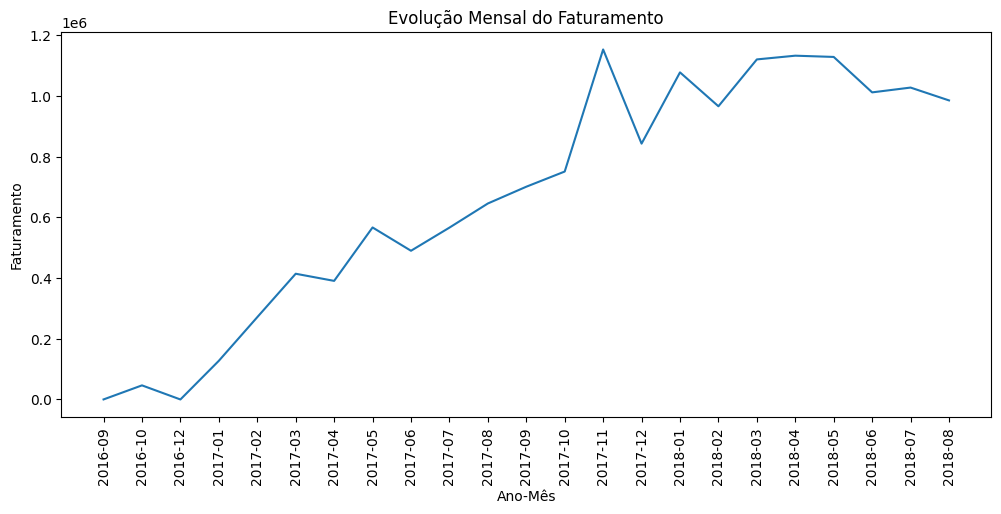

In [40]:
plt.figure(figsize=(12,5))
plt.plot(faturamento_mensal['ano_mes'], faturamento_mensal['faturamento_total'])
plt.xticks(rotation=90)
plt.title('Evolução Mensal do Faturamento')
plt.xlabel('Ano-Mês')
plt.ylabel('Faturamento')
plt.show()

## Desafio BI - montar uma consulta que responda “top 10 produtos por receita”.

In [45]:
# TOP 10 produtos por receita de vendas
con.sql("""
SELECT
    p.product_id,
    p.product_category_name_english AS categoria,
    SUM(f.valor_total) AS faturamento_total
FROM dim_produto p
INNER JOIN fato_vendas f
    ON p.produto_sk = f.produto_sk
GROUP BY p.product_id, p.product_category_name_english
ORDER BY faturamento_total DESC
LIMIT 10
""").df()

,product_id,categoria,faturamento_total
0,bb50f2e236e5eea0100680137654686c,health_beauty,67258.03
1,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,58957.31
2,6cdd53843498f92890544667809f1595,health_beauty,57933.73
3,99a4788cb24856965c36a24e339b6058,bed_bath_table,49907.50
4,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,47876.06
5,d6160fb7873f184099d9bc95e30376af,computers,47314.18
6,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,44197.75
7,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,41725.81
8,25c38557cf793876c5abdd5931f922db,baby,40311.95
9,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,39713.49
